In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, TimeDistributed
from tensorflow.keras.models import Model
import gc
import matplotlib.pyplot as plt

In [ ]:
import sys
sys.path.append('../data_preprocessing')

In [ ]:
import RNN_preprocessing_sep_chain as rp 

In [ ]:
X1_seq_train = rp.X1_seq_train
X1_seq_test = rp.X1_seq_test
y1_seq_train = rp.y1_seq_train
y1_seq_test = rp.y1_seq_test
X2_seq_train = rp.X2_seq_train
X2_seq_test = rp.X2_seq_test
y2_seq_train = rp.y2_seq_train
y2_seq_test = rp.y2_seq_test

In [ ]:
# Clear memory associated with the module
import sys
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
gc.collect()

6

In [ ]:
X1_train, X1_val, y1_train, y1_val = train_test_split(X1_seq_train, y1_seq_train, test_size=0.2, random_state=0)

In [ ]:
X2_train, X2_val, y2_train, y2_val = train_test_split(X2_seq_train, y2_seq_train, test_size=0.2, random_state=0)

LSTM

In [6]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def call(self, inputs):
        """
        Applies attention mechanism to the inputs.

        Args:
            inputs: Tensor of shape (batch_size, seq_length, features).

        Returns:
            Tensor of shape (batch_size, features).
        """
        query = inputs  # Use the same input as query, key, and value
        key = inputs
        value = inputs

        # Compute attention scores
        scores = tf.matmul(query, key, transpose_b=True)  # Shape: (batch, seq_length, seq_length)
        scores = tf.nn.softmax(scores, axis=-1)  # Normalize scores

        # Weighted sum of the values
        context = tf.matmul(scores, value)  # Shape: (batch, seq_length, features)

        return context


In [7]:
def build_bilstm_with_attention(input_shape, num_classes):
    """
    Builds a BiLSTM model with an attention mechanism.

    Args:
        input_shape (tuple): Shape of the input data (seq_length, num_features).
        num_classes (int): Number of output classes.

    Returns:
        keras.Model: Compiled BiLSTM model with attention.
    """
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Attention()(x)  # Add attention mechanism
    x = TimeDistributed(Dense(64, activation="relu"))(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [8]:
seq_length = 10

In [9]:
#Model for the BiPo 214 chain
model1 = build_bilstm_with_attention((seq_length, X1_train.shape[2]), y1_train.shape[2])

model1.summary()

2025-01-28 16:06:30.997304: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 128)           36352     
 al)                                                             
                                                                 
 attention (Attention)       (None, 10, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 10, 64)            8256      
 ributed)                                                        
                                                                 
 dense_1 (Dense)             (None, 10, 4)             260       
                                                                 
Total params: 44868 (175.27 KB)
Trainable params: 44868 (175.

In [40]:
#Model for the BiPo 212 chain
model2 = build_bilstm_with_attention((seq_length, X2_train.shape[2]), y2_train.shape[2])
model2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10, 6)]           0         
                                                                 
 bidirectional (Bidirection  (None, 10, 128)           36352     
 al)                                                             
                                                                 
 attention (Attention)       (None, 10, 128)           0         
                                                                 
 time_distributed (TimeDist  (None, 10, 64)            8256      
 ributed)                                                        
                                                                 
 dense_1 (Dense)             (None, 10, 6)             390       
                                                                 
Total params: 44998 (175.77 KB)
Trainable params: 44998 (175.

In [10]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [11]:
# Clear any previous session
tf.keras.backend.clear_session()
gc.collect()


6184

In [13]:
y1_train.shape

(1611564, 10, 4)

In [12]:
# Train model 1
history1 = model1.fit(X1_train, y1_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_val, y1_val),
                      callbacks=callbacks)

Epoch 1/200
6296/6296 - 361s - loss: 0.3133 - accuracy: 0.8750 - val_loss: 0.1903 - val_accuracy: 0.9288 - lr: 0.0010 - 361s/epoch - 57ms/step
Epoch 2/200
6296/6296 - 349s - loss: 0.1781 - accuracy: 0.9329 - val_loss: 0.1707 - val_accuracy: 0.9349 - lr: 0.0010 - 349s/epoch - 56ms/step
Epoch 3/200
6296/6296 - 338s - loss: 0.1672 - accuracy: 0.9364 - val_loss: 0.1651 - val_accuracy: 0.9367 - lr: 0.0010 - 338s/epoch - 54ms/step
Epoch 4/200
6296/6296 - 341s - loss: 0.1628 - accuracy: 0.9378 - val_loss: 0.1646 - val_accuracy: 0.9374 - lr: 0.0010 - 341s/epoch - 54ms/step
Epoch 5/200
6296/6296 - 310s - loss: 0.1597 - accuracy: 0.9388 - val_loss: 0.1591 - val_accuracy: 0.9390 - lr: 0.0010 - 310s/epoch - 49ms/step
Epoch 6/200
6296/6296 - 240s - loss: 0.1581 - accuracy: 0.9393 - val_loss: 0.1573 - val_accuracy: 0.9396 - lr: 0.0010 - 240s/epoch - 38ms/step
Epoch 7/200
6296/6296 - 240s - loss: 0.1573 - accuracy: 0.9396 - val_loss: 0.1581 - val_accuracy: 0.9392 - lr: 0.0010 - 240s/epoch - 38ms/step

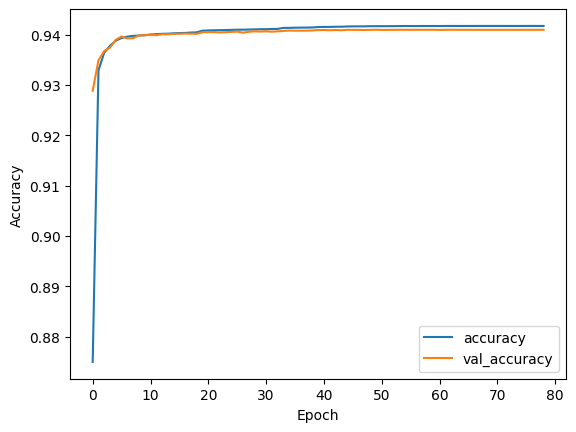

In [13]:
#plotting the accuracy of the first model
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

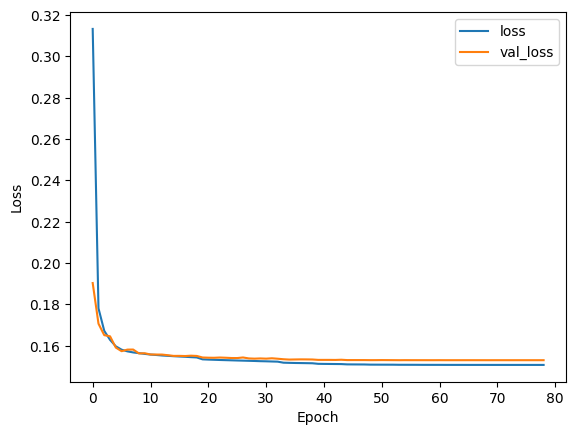

In [14]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
#save the first trained model
model1.save('../models/model_bidirec_lstm_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Model 212

In [ ]:
# Train model 2
history2 = model2.fit(X2_train, y2_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_val, y2_val),
                      callbacks=callbacks)

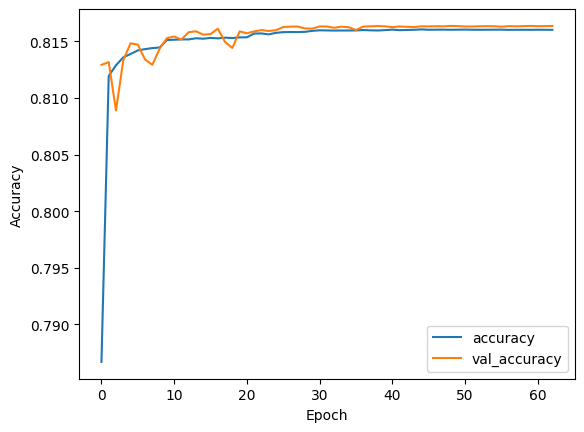

In [7]:
#plotting the accuracy of the second model
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

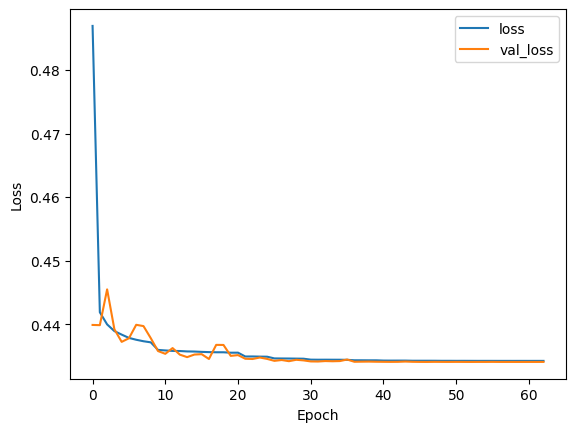

In [8]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [12]:
#save the second trained model
model2.save('model_bidirec_lstm_212.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 